In [4]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
# Load dataset
df = pd.read_csv("fruits.csv")

# Standardize column names
df.columns = df.columns.str.lower()

# Keep a copy for EDA plots (IMPORTANT)
df_raw = df.copy()

df.head()

,fruit_id,fruit_type,size_cm,weight_g,color_intensity,ripeness_level,firmness,sweetness,defect_count,bruise_score,spot_score,defect_score,size_to_weight_ratio,grade
0,FR00001,Peach,5.98,141.19,0.40,0.08,0.91,0.18,0,0.05,0.60,0.14,4.24,Reject
1,FR00002,Orange,7.60,154.18,0.34,0.57,0.04,0.51,1,0.10,0.44,0.17,4.93,Local
2,FR00003,Pear,9.99,207.51,0.58,0.39,0.12,0.54,2,0.42,0.45,0.32,4.82,Reject
3,FR00004,Grapes,1.86,4.54,0.34,0.48,0.94,0.76,2,0.48,0.65,0.38,40.93,Local
4,FR00005,Peach,6.13,154.68,0.78,0.63,0.13,0.35,0,0.38,0.72,0.26,3.96,Local


In [6]:
# DATA UNDERSTANDING

# Shape of dataset
print("Shape:", df.shape)

# Columns
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (10000, 14)

Columns:
 Index(['fruit_id', 'fruit_type', 'size_cm', 'weight_g', 'color_intensity',
       'ripeness_level', 'firmness', 'sweetness', 'defect_count',
       'bruise_score', 'spot_score', 'defect_score', 'size_to_weight_ratio',
       'grade'],
      dtype='object')

Data Types:
 fruit_id                 object
fruit_type               object
size_cm                 float64
weight_g                float64
color_intensity         float64
ripeness_level          float64
firmness                float64
sweetness               float64
defect_count              int64
bruise_score            float64
spot_score              float64
defect_score            float64
size_to_weight_ratio    float64
grade                    object
dtype: object

Missing Values:
 fruit_id                0
fruit_type              0
size_cm                 0
weight_g                0
color_intensity         0
ripeness_level          0
firmness                0
sweetness               0
defect_coun

fruit_type
Apple          1053
Watermelon     1034
Pomegranate    1021
Peach          1017
Mango           996
Strawberry      994
Banana          985
Orange          971
Pear            967
Grapes          962
Name: count, dtype: int64


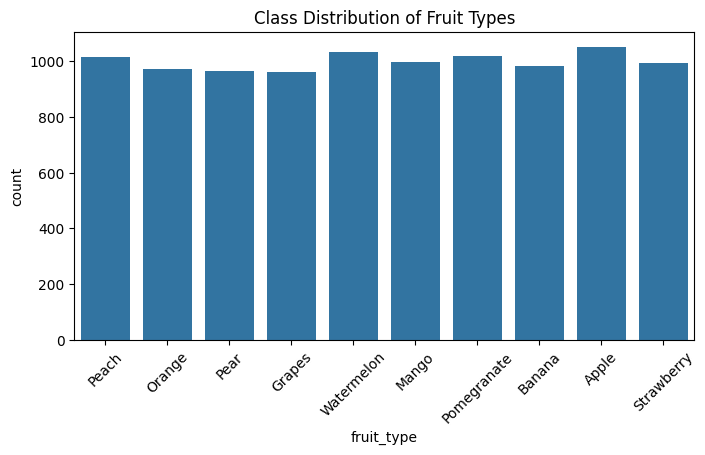

In [7]:
# TARGET VARIABLE ANALYSIS

target = "fruit_type"

# Class distribution
print(df[target].value_counts())

# Visualization
plt.figure(figsize=(8,4))
sns.countplot(data=df, x=target)
plt.xticks(rotation=45)
plt.title("Class Distribution of Fruit Types")
plt.show()

In [8]:
# FEATURE TYPES

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# remove ID columns if present
if "fruit_id" in num_cols:
    num_cols.remove("fruit_id")

print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)

Numerical Features: ['size_cm', 'weight_g', 'color_intensity', 'ripeness_level', 'firmness', 'sweetness', 'defect_count', 'bruise_score', 'spot_score', 'defect_score', 'size_to_weight_ratio']
Categorical Features: ['fruit_id', 'fruit_type', 'grade']


In [9]:
# MISSING VALUE HANDLING

# No missing values in dataset (but pipeline included for real-world use)

# Numerical → median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
fruit_id,0
fruit_type,0
size_cm,0
weight_g,0
color_intensity,0
ripeness_level,0
firmness,0
sweetness,0
defect_count,0
bruise_score,0


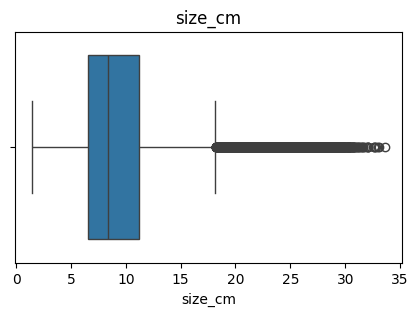

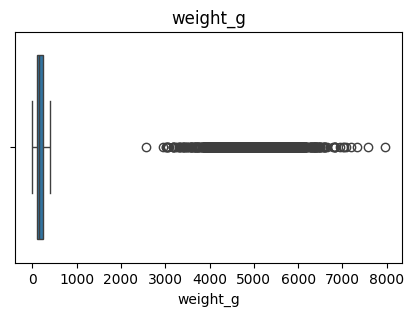

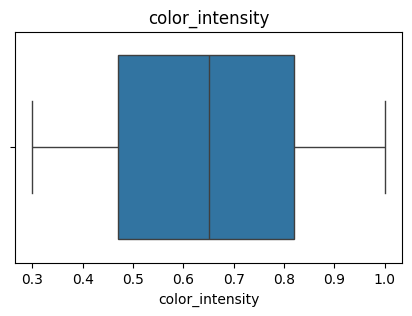

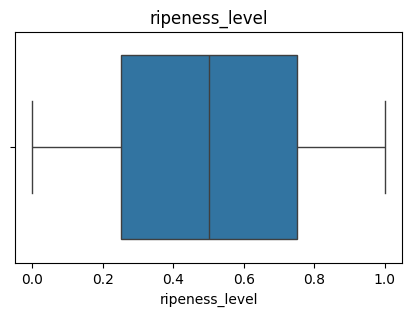

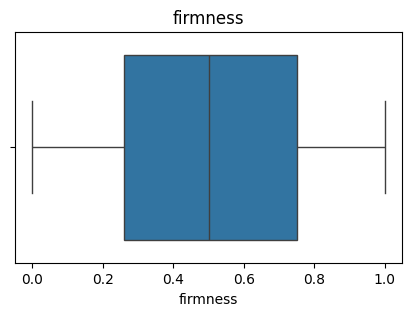

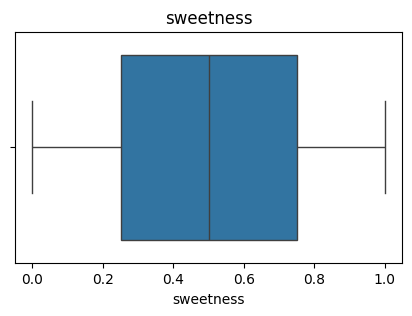

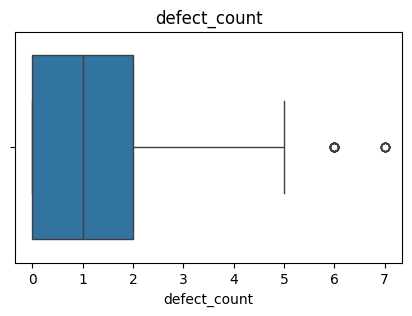

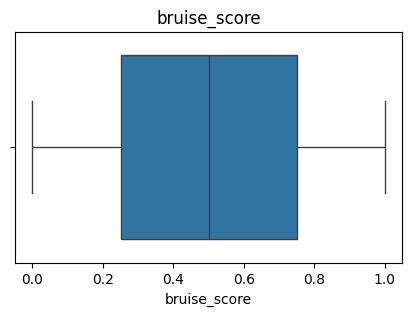

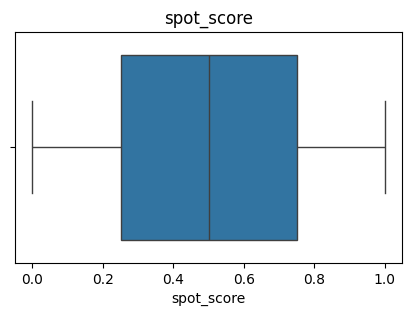

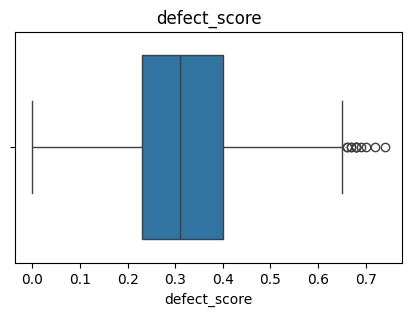

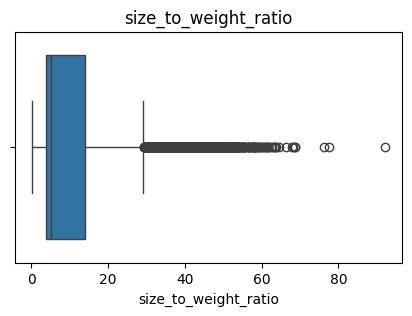

In [10]:
# OUTLIER DETECTION (BOXPLOT)

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
# ============================
# GROUP-WISE OUTLIER HANDLING (IQR CAPPING)
# ============================

cols_to_cap = ["size_cm", "weight_g", "size_to_weight_ratio"]

# remove inf values before outlier handling
df[cols_to_cap] = df[cols_to_cap].replace([np.inf, -np.inf], np.nan)

# fill NaN (if created due to inf removal)
for col in cols_to_cap:
    df[col] = df[col].fillna(df[col].median())

def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return series.clip(lower, upper)

# Apply outlier capping inside each fruit type
df[cols_to_cap] = df.groupby("fruit_type")[cols_to_cap].transform(cap_outliers)

print("Group-wise IQR capping applied on:", cols_to_cap)

Group-wise IQR capping applied on: ['size_cm', 'weight_g', 'size_to_weight_ratio']


In [12]:
# ============================
# LOG TRANSFORMATION (SKEWNESS HANDLING)
# ============================

log_cols = ["size_cm", "weight_g", "size_to_weight_ratio"]

for col in log_cols:
    # log1p requires values >= 0
    df[col] = df[col].clip(lower=0)
    df[col] = np.log1p(df[col])

print("Log transformation applied safely on:", log_cols)

Log transformation applied safely on: ['size_cm', 'weight_g', 'size_to_weight_ratio']


In [13]:
# ============================
# CHECK SKEWNESS AFTER LOG TRANSFORMATION
# ============================

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Skewness after log transformation:\n")
print(df[num_cols].skew())

Skewness after log transformation:

size_cm                -0.154893
weight_g                0.169889
color_intensity         0.008746
ripeness_level         -0.000669
firmness               -0.005151
sweetness              -0.013887
defect_count            0.885354
bruise_score           -0.006133
spot_score             -0.011859
defect_score            0.069752
size_to_weight_ratio    0.283196
dtype: float64


In [14]:
# ============================
# ROBUST SCALING (MEDIAN + IQR BASED)
# ============================

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# scale only numeric columns
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Robust Scaling applied successfully!")
df.head()

Robust Scaling applied successfully!


,fruit_id,fruit_type,size_cm,weight_g,color_intensity,ripeness_level,firmness,sweetness,defect_count,bruise_score,spot_score,defect_score,size_to_weight_ratio,grade
0,FR00001,Peach,-0.619354,-0.138808,-0.714286,-0.84,0.836735,-0.64,-0.5,-0.90,0.20,-1.000000,-0.139536,Reject
1,FR00002,Orange,-0.185076,-0.021598,-0.885714,0.14,-0.938776,0.02,0.0,-0.80,-0.12,-0.823529,-0.029505,Local
2,FR00003,Pear,0.325170,0.374461,-0.200000,-0.22,-0.775510,0.08,0.5,-0.16,-0.10,0.058824,-0.046159,Reject
3,FR00004,Grapes,-2.475845,-4.489762,-0.885714,-0.04,0.897959,0.52,0.5,-0.04,0.30,0.411765,1.710301,Local
4,FR00005,Peach,-0.575113,-0.017285,0.371429,0.26,-0.755102,-0.30,-0.5,-0.24,0.44,-0.294118,-0.188382,Local


In [15]:
# ============================
# LABEL ENCODING
# ============================

from sklearn.preprocessing import LabelEncoder

target = "fruit_type"

le = LabelEncoder()
df[target + "_encoded"] = le.fit_transform(df[target])

print("Fruit Type Encoding Mapping:\n")
for i, cls in enumerate(le.classes_):
    print(cls, "->", i)

Fruit Type Encoding Mapping:

Apple -> 0
Banana -> 1
Grapes -> 2
Mango -> 3
Orange -> 4
Peach -> 5
Pear -> 6
Pomegranate -> 7
Strawberry -> 8
Watermelon -> 9


In [16]:
# ============================
# DATA SPLITTING (70/15/15)
# ============================

X = df.drop(columns=[target, target + "_encoded"], errors="ignore")

# drop fruit_id if exists (not useful feature)
if "fruit_id" in X.columns:
    X = X.drop(columns=["fruit_id"])

y = df[target + "_encoded"]

# Train + Temp (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Validation + Test (15% / 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

Train Shape: (7000, 12)
Validation Shape: (1500, 12)
Test Shape: (1500, 12)


In [17]:
# ============================
# SAVE FINAL DATASETS
# ============================

X_train.to_csv("X_train.csv", index=False)
X_val.to_csv("X_val.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Datasets saved successfully!")

Datasets saved successfully!


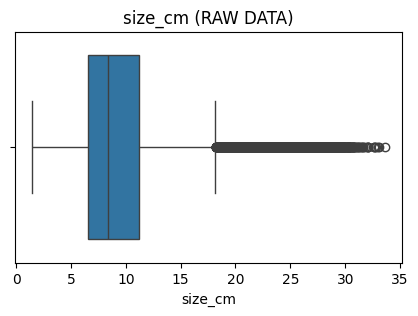

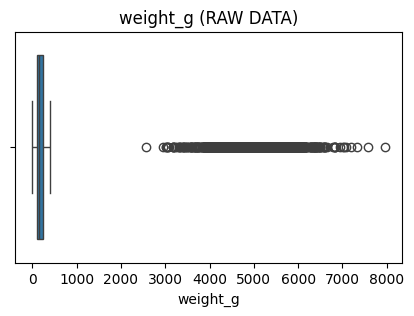

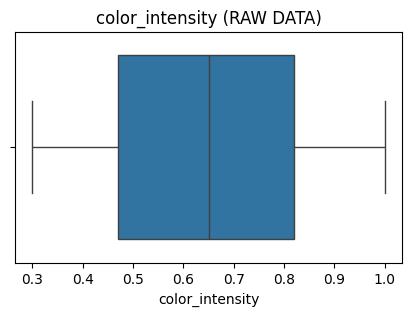

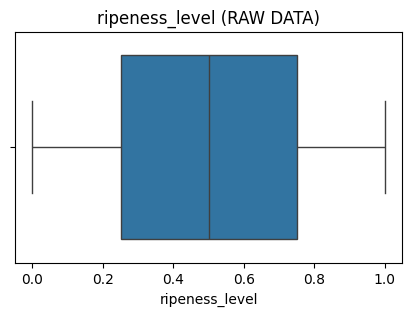

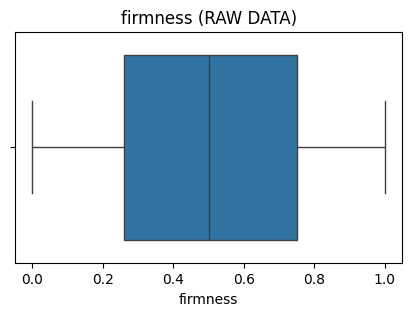

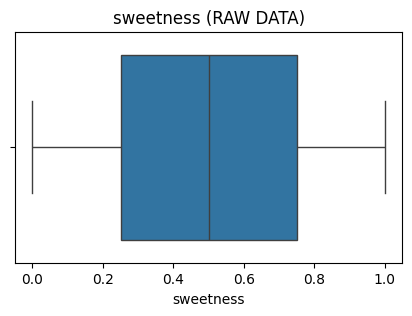

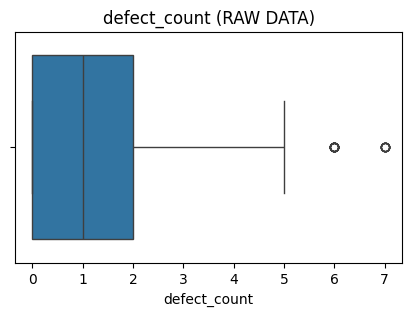

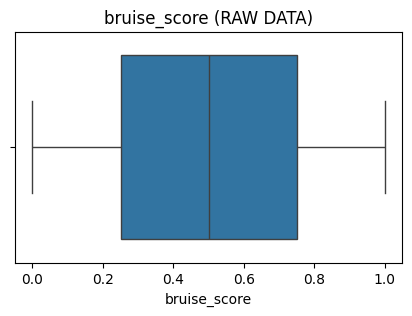

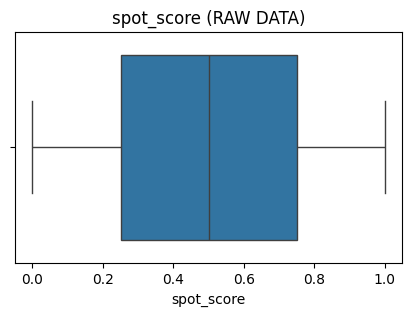

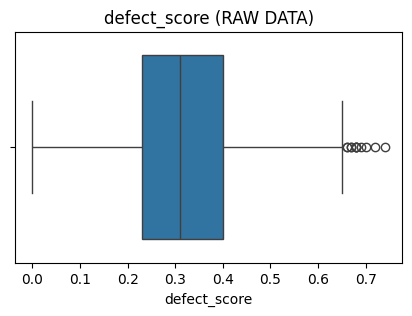

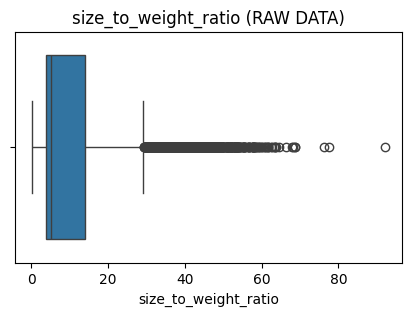

In [18]:
# OUTLIER DETECTION (BOXPLOT) - RAW DATA FOR VISUALIZATION

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df_raw[col])
    plt.title(f"{col} (RAW DATA)")
    plt.show()